In [43]:
import os
os.getcwd()

'/home/yyu27/D-PACKAGE'

In [44]:
# import anndata
import numpy as np
import pandas as pd

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.distributions import MultivariateNormal

import os
# os.environ["CUDA_VISIBLE_DEVICES"]="4"

import copy

import tqdm

from typing import List, Union

In [45]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [46]:
from codes.utils.util import *
from codes.drugcell_NN import *

In [47]:
if torch.cuda.is_available():
  DEVICE = 'cuda'
else:
  DEVICE = 'cpu'
  
torch.cuda.device_count()

1

In [48]:
torch.cuda.device_count()

1

In [49]:
!nvidia-smi

Fri Oct 10 13:48:33 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.05              Driver Version: 560.35.05      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          On  |   00000000:C1:00.0 Off |                   On |
| N/A   27C    P0             84W /  500W |      91MiB /  81920MiB |     N/A      Default |
|                                         |                        |              Enabled |
+-----------------------------------------+-----

In [50]:
if torch.cuda.is_available():
      DEVICE = 'cuda'
else:
  DEVICE = 'cpu'

In [51]:
retrain = False

# Data Loading

## TCGA

In [52]:
class RNASeqData(Dataset):
    
    def __init__(self, X, c=None, y=None, transform=None):
        self.X = X
        self.y = y
        self.c = c
        self.transform = transform
        
    def __len__(self):
        return self.X.shape[0]
    
    def __getitem__(self, index):
        sample = self.X[index,:]
        
        if self.transform is not None:
            sample = self.transform(sample)
        
        if self.y is not None and self.c is None:
            return sample, self.y[index]
        elif self.y is not None and self.c is not None:
            return sample, self.y[index], self.c[index]
        elif self.y is None and self.c is not None:
            return sample, self.c[index]
        else:
            return sample

In [53]:
## expression and IHC data

rna_seq = pd.read_csv('data/test_tcga_expression_matrix_processed.tsv.gz',sep='\t',index_col=0)
# abeta_data = pd.read_csv('data/alzheimers-disease-gene-modules-master-data-preprocessed_data/data/preprocessed_data/All_Datasets_Abeta_IHC_Labels.tsv',index_col=0,sep='\t')

In [54]:
rna_seq.shape

(1106, 16148)

In [55]:
tcga_mad_genes = pd.read_csv('data/tcga_mad_genes.tsv', sep='\t')
tcga_sample_counts = pd.read_csv('data/tcga_sample_counts.tsv', sep='\t')

In [56]:
# rna_seq = rna_seq.loc[:,tcga_mad_genes.gene_id[:3000].apply(str)]
rna_seq = rna_seq / rna_seq.std()
rna_seq = np.log(rna_seq + 1)

In [57]:
rna_seq.shape

(1106, 16148)

In [58]:
tcga_sample_identifiers = pd.read_csv('data/tcga_sample_identifiers.tsv', sep='\t',index_col=0)

In [59]:
tcga_sample_identifiers

,sample_type,cancer_type
sample_id,,
TCGA-02-0047-01,Primary Solid Tumor,GBM
TCGA-02-0055-01,Primary Solid Tumor,GBM
TCGA-02-2483-01,Primary Solid Tumor,GBM
TCGA-02-2485-01,Primary Solid Tumor,GBM
TCGA-02-2486-01,Primary Solid Tumor,GBM
...,...,...
TCGA-ZS-A9CG-01,Primary Solid Tumor,LIHC
TCGA-ZT-A8OM-01,Primary Solid Tumor,THYM
TCGA-ZU-A8S4-01,Primary Solid Tumor,CHOL


In [60]:
# meta data labels 
# dataset_labels = pd.read_csv('data/alzheimers-disease-gene-modules-master-data-preprocessed_data/data/preprocessed_data/All_Dataset_Labels.tsv',index_col=0,sep='\t')
# region_labels = pd.read_csv('data/alzheimers-disease-gene-modules-master-data-preprocessed_data/data/preprocessed_data/All_Joined_Region_Labels.tsv',index_col=0,sep='\t')

### Transfer the entrezgene_id to hgnc_symbol

In [61]:
tcga_df = rna_seq

In [62]:
tcga_df.columns

Index(['1', '10', '100', '1000', '10000', '10001', '10002', '10003',
       '100037417', '10004',
       ...
       '9987', '9988', '9989', '999', '9990', '9991', '9992', '9993', '9994',
       '9997'],
      dtype='object', length=16148)

In [63]:
gene_id_dict = pd.read_csv('data/gene_dict.csv')

In [64]:
gene_id_dict[gene_id_dict.entrezgene_id == 213]

,hgnc_symbol,entrezgene_id,gene_biotype,description
3432,ALB,213,protein_coding,albumin [Source:HGNC Symbol;Acc:HGNC:399]


In [65]:
new_column = []
for col_name in tcga_df.columns:
    col_loc = (gene_id_dict.entrezgene_id == int(col_name))
    if np.sum(col_loc) == 0:
        tcga_df = tcga_df.drop(columns = col_name)
    else:
        new_column.append(gene_id_dict.hgnc_symbol[gene_id_dict.entrezgene_id == int(col_name)].iloc[0])

In [66]:
len(new_column)

16100

In [67]:
tcga_df.shape

(1106, 16100)

In [68]:
tcga_df.columns = new_column

# DCell

In [69]:
training_file = "data/drugcell_train.txt"
testing_file = "data/drugcell_test.txt"
val_file = "data/drugcell_val.txt"
cell2id_file = "data/cell2ind.txt"
drug2id_file = "data/drug2ind.txt"
genotype_file = "data/cell2mutation.txt"
fingerprint_file = "data/drug2fingerprint.txt"
onto_file = "data/drugcell_ont.txt"
gene2id_file = "data/gene2ind.txt"

train_data, feature_dict, cell2id_mapping, drug2id_mapping = prepare_train_data(training_file, 
                                                                  testing_file, cell2id_file, 
                                                                  drug2id_file)

gene2id_mapping = load_mapping(gene2id_file)

# load cell/drug features
cell_features = np.genfromtxt(genotype_file, delimiter=',')
drug_features = np.genfromtxt(fingerprint_file, delimiter=',')

num_cells = len(cell2id_mapping)
num_drugs = len(drug2id_mapping)
num_genes = len(gene2id_mapping)
drug_dim = len(drug_features[0,:])

# load ontology
dG, root, term_size_map, \
    term_direct_gene_map = load_ontology(onto_file, 
                                         gene2id_mapping)

Total number of cell lines = 1225
Total number of drugs = 684
There are 3008 genes
There are 1 roots: GO:0008150
There are 2086 terms
There are 1 connected componenets


In [70]:
train_feature, train_label, test_feature, test_label = train_data

In [71]:
train_loader = du.DataLoader(du.TensorDataset(train_feature,train_label),
                                 batch_size=32, shuffle=False)

In [72]:
for i, (inputdata, labels) in enumerate(train_loader):
    features = build_input_vector(inputdata, cell_features, drug_features)
    break

In [73]:
cell_features.shape

(1225, 3008)

In [74]:
features.shape

torch.Size([32, 5056])

## Find the intersection of TCGA and DCell genes

In [75]:
len(list(set(gene2id_mapping.keys()) & set(tcga_df.columns)))

2702

In [76]:
len(gene2id_mapping.keys())

3008

### Create gene2ID for tcga

In [77]:
tcga_gene2id = {}
for idx, gene in enumerate(tcga_df.columns):
    tcga_gene2id[gene] = idx

In [78]:
# num_genes = len(tcga_gene2id)
# # load ontology
# dG, root, term_size_map, \
#     term_direct_gene_map = load_ontology(onto_file, 
#                                          tcga_gene2id)

### Align gene id with tcga

In [79]:
gene_intersect_list = list(set(gene2id_mapping.keys()) & set(tcga_df.columns))
tcga_tensor = torch.zeros(tcga_df.shape[0], num_genes)

In [80]:
for gene in tqdm.tqdm(gene_intersect_list):
    idx = gene2id_mapping[gene]
    tcga_tensor[:,idx] = torch.tensor(tcga_df[gene])

100%|██████████| 2702/2702 [00:08<00:00, 313.38it/s]


(array([  2.,  27., 193., 443., 312.,  96.,  29.,   3.,   0.,   1.]),
 array([2.37834104e-03, 2.81129211e-01, 5.59880137e-01, 8.38630974e-01,
        1.11738193e+00, 1.39613271e+00, 1.67488360e+00, 1.95363450e+00,
        2.23238540e+00, 2.51113629e+00, 2.78988719e+00]),
 <BarContainer object of 10 artists>)

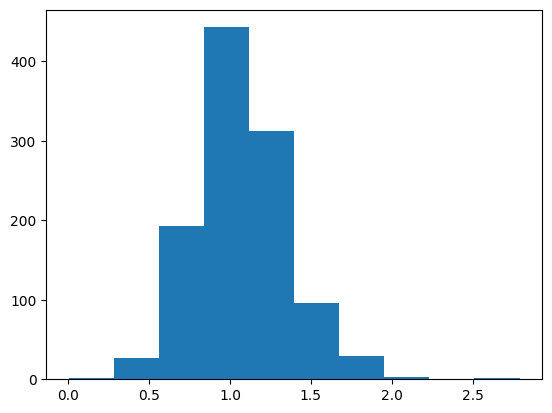

In [81]:
plt.hist(tcga_tensor[:,4])

In [82]:
cancer_type = tcga_sample_identifiers.loc[tcga_df.index, 'cancer_type']
cancer_type.value_counts()

cancer_type
BRCA    122
KIRC     60
THCA     59
LUAD     57
UCEC     56
HNSC     56
PRAD     55
LUSC     55
LGG      53
COAD     49
SKCM     47
STAD     45
BLCA     43
LIHC     42
KIRP     33
OV       31
CESC     31
SARC     26
ESCA     19
PCPG     19
PAAD     18
GBM      17
READ     17
LAML     17
TGCT     16
THYM     12
KICH     10
MESO      9
ACC       8
UVM       8
UCS       6
DLBC      5
CHOL      5
Name: count, dtype: int64

In [83]:
cancer_2_idx = {}
idx_2_cancer = {}
cancer_type_idx = []

i = 0
for cancer in cancer_type:
    if cancer not in cancer_2_idx:
        cancer_2_idx[cancer] = i
        idx_2_cancer[i] = cancer
        cancer_type_idx.append(i)
        
        i += 1
    else:
        cancer_type_idx.append(cancer_2_idx[cancer])

In [84]:
y = torch.tensor(cancer_type_idx)

In [85]:
torch.manual_seed(0)
tcga_dataset = RNASeqData(X = tcga_tensor, y = y)
training_set, testing_set = random_split(tcga_dataset, [0.7, 0.3])

In [86]:
next(iter(training_set))

(tensor([0.1034, 0.3446, 0.7321,  ..., 0.2336, 1.1648, 0.9586]), tensor(2))

(array([ 56.,  31.,  55.,  53.,  31.,  60., 122.,  17.,  42.,  57.,  49.,
         55.,  56.,  43.,  33.,  59.,  19.,  19.,  17.,  45.,  47.,  18.,
         26.,   8.,  12.,  16.,  17.,  10.,   9.,   6.,   8.,  10.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29., 30., 31., 32.]),
 <BarContainer object of 32 artists>)

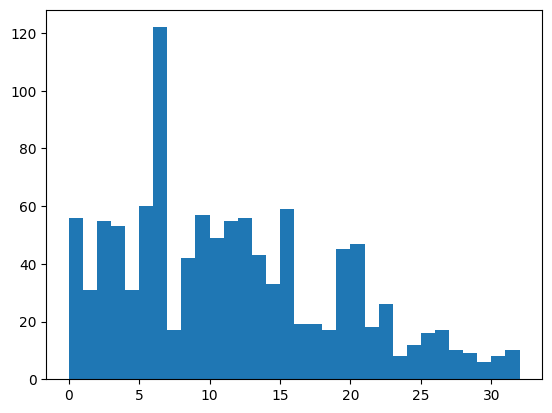

In [87]:
plt.hist(y, bins = 32)

In [88]:
cancer_2_idx

{'HNSC': 0,
 'CESC': 1,
 'LUSC': 2,
 'LGG': 3,
 'OV': 4,
 'KIRC': 5,
 'BRCA': 6,
 'READ': 7,
 'LIHC': 8,
 'LUAD': 9,
 'COAD': 10,
 'PRAD': 11,
 'UCEC': 12,
 'BLCA': 13,
 'KIRP': 14,
 'THCA': 15,
 'ESCA': 16,
 'PCPG': 17,
 'GBM': 18,
 'STAD': 19,
 'SKCM': 20,
 'PAAD': 21,
 'SARC': 22,
 'ACC': 23,
 'THYM': 24,
 'TGCT': 25,
 'LAML': 26,
 'KICH': 27,
 'MESO': 28,
 'UCS': 29,
 'UVM': 30,
 'DLBC': 31,
 'CHOL': 32}

In [89]:
tcga_tensor

tensor([[7.6418e-03, 4.9368e-02, 1.0971e+00,  ..., 8.3553e-02, 1.0168e+00,
         5.2852e-01],
        [1.4095e-03, 8.2211e-01, 6.3336e-01,  ..., 3.8650e-01, 8.8934e-01,
         4.9280e-01],
        [8.6245e-02, 4.5868e-01, 7.2176e-01,  ..., 2.3745e-01, 7.4846e-01,
         6.2926e-01],
        ...,
        [1.3164e-04, 1.3562e-01, 6.5725e-01,  ..., 1.7342e-01, 1.2802e+00,
         1.2972e+00],
        [0.0000e+00, 3.5566e-01, 8.3660e-01,  ..., 7.2419e-02, 8.7412e-01,
         9.2905e-01],
        [6.4317e-04, 2.5109e-01, 1.5179e+00,  ..., 4.0108e-02, 1.3588e+00,
         9.5861e-01]])